# 1D Poisson Equation

**<span style="color: red;">The layout and text of this notebook are based on the original document: 1. Defining your own problem - 1D harmonic oscillator.</span>**

> Note: The examples in this directory assume basic familiarity with PINNs. If you are new to PINNs, check out this [blog post](https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/) first.

# Problem overview

In this example we will use a (multi-level) FBPINN to solve the 1D Poisson Equation, which is the following ordinary differential equation (ODE):

$$
u'' = f~,
$$

on the domain $\Omega = (0,1)$ with boundary conditions $u(0) = u(1) = 0$ and for some function $f$ to be defined. In this case, we would like to investigate how well (multi-level) FBPINNs solve a differential equation containing a high-frequency components. Therefore, $f$ is defined as follows,

$$
f(t) = \sum_{i = 1}^{n} a_i \sin(b_i \pi t),
$$

with $n \in \mathbb{N}^+$ and $a_i, b_i \in \mathbb{R^+}$ for $i=1,\ldots, n$. For this particular case, the **exact solution** is known and given by:

$$
u(t) = - \sum_{i = 1}^{n} \dfrac{a_i}{\pi^2 b_i^2} \sin(b_i \pi t).
$$

It is expected that lower frequency components are learned faster than the higher ones, but that FBPINNs will learn these higher components faster than PINNs.

# How (FB)PINNs solve this problem


PINNs use a neural network with trainable parameters $\theta$ to **directly approximate** the solution to the differential equation, i.e.

$$
N\!N(t;\theta) \approx u(t)~,
$$

Then, to learn the solution to the problem above (i.e. train the network), the following **loss function** is used:

$$
\mathcal{L}(\theta)= (N\!N(0;\theta) - 0)^2 +(N\!N(1;\theta) - 0)^2 + \frac{\lambda}{N} \sum^{N}_{i} \left( \partial_{tt}N\!N(t_{i};\theta) - f(t_i) \right)^2
$$

The first two terms are known as the **boundary loss**, which try to ensure the boundary conditions are obeyed, and the last term is known as the **physics loss**, which minimises the residual of the differential equation throughout the problem domain. $\{t_{i}\}_{i=1}^N$ are a set of collocation points (coordinates) sampled throughout the problem domain used to evaluate the physics loss, and $\lambda$ is a scalar hyperparameter used to control the balence between the different terms in the loss function.

> Note: FBPINNs are trained using exactly the **same** loss function as PINNs - the only difference is that the neural network $N\!N(t;\theta)$ above is replaced by a summation over all subdomain networks in the FBPINN.

# Workflow overview

We will use the following steps to define and train the FBPINN:

1. Define the **problem domain**, by using the `fbpinns.domains.RectangularDomainND` class
2. Define the **ODE** to solve, and its **problem constraints**, by defining our own `fbpinns.problems.Problem` class
3. Define the **domain decomposition** used by the FBPINN, by using the `fbpinns.decompositions.RectangularDecompositionND` class
4. Define the **neural network** placed in each subdomain, by using the `fbpinns.networks.FCN` class
5. Pass these classes and their initialisation values to a `fbpinns.constants.Constants` object
6. Start the FBPINN training by instantiating a `fbpinns.trainer.FBPINNTrainer` using the `Constants` object.

## Step 1: Define problem domain

For this example, we will use the existing `fbpinns.domains.RectangularDomainND` class to define the problem domain. In this case all we need to do is define the initialisation values of this class:

In [1]:
import numpy as np
from fbpinns.domains import RectangularDomainND

domain = RectangularDomainND
domain_init_kwargs = dict(
    xmin=np.array([0.,]),
    xmax=np.array([1.,]),# solve the problem over the domain [0, 1]
)

## Step 2: Define the ODE to solve

Next, we will define our own `fbpinns.problems.Problem` class to define the ODE to solve. The important things we must define in this class are:

1. The **problem constraints**: these are all the input points, any supervised labels, and the solution and gradients components required to evaluate each term (i.e. constraint) in the loss function
2. The **loss function** used to train the FBPINN, given these constraints
3. The **exact solution**, if it exists, used to test the FBPINN during training


### Inheriting the `Problem` class

All problem classes should inherit from the base `fbpinns.problems.Problem` class.

In [2]:
import jax.numpy as jnp
from fbpinns.problems import Problem

The base `Problem` class is shown below:

```python
class Problem:
    """Base problem class to be inherited by different problem classes.

    Note all methods in this class are jit compiled / used by JAX,
    so they must not include any side-effects!
    (A side-effect is any effect of a function that doesn’t appear in its output)
    This is why only static methods are defined.
    """

    # required methods

    @staticmethod
    def init_params(*args):
        """Initialise class parameters.
        Returns tuple of dicts ({k: pytree}, {k: pytree}) containing static and trainable parameters"""

        # below parameters need to be defined
        static_params = {
            "dims":None,# (ud, xd)# dimensionality of u and x
            }
        raise NotImplementedError

    @staticmethod
    def sample_constraints(all_params, domain, key, sampler, batch_shapes):
        """Samples all constraints.
        Returns [[x_batch, *any_constraining_values, required_ujs], ...]. Each list element contains
        the x_batch points and any constraining values passed to the loss function, and the required
        solution and gradient components required in the loss function, for each constraint."""
        raise NotImplementedError

    @staticmethod
    def loss_fn(all_params, constraints):
        """Computes the PINN loss function, using constraints with the same structure output by sample_constraints"""
        raise NotImplementedError

    @staticmethod
    def exact_solution(all_params, x_batch, batch_shape=None):
        """Defines exact solution, if it exists"""
        raise NotImplementedError
```

### A note on functional programming

Before we explain how to implement each method, it is important to understand the semantics of the class. 

> `fbpinns` uses [JAX](https://jax.readthedocs.io/en/latest/index.html) as its main computational engine. To be able to use JAX effectively (in particular its `jit` compilation), we need to write **[functionally pure](https://jax.readthedocs.io/en/latest/jax-101/07-state.html)** code. This means that any functions we write which are compiled (which include most of the class methods above) should not have any **side-effects** - that is, all the input data is passed through the function parameters, all the results are output through the function results. An important consequence of this is that we should not refer to, or update, the class state (i.e. use `self` in standard Python classes), as this may have unexpected consequences.

To ensure functionally purity, all the class methods above are defined as `staticmethods`, and any initial parameters of the class (output by `init_params`) are explicitly passed to each method in the `all_params` argument (rather than saving them to `self`).


### `Problem.init_params(*args)`

The `init_params` method intialises any **static** and **trainable** problem parameters.

It should return two dictionaries, one containing static parameters and the other containing trainable parameters.

For our problem, we do not want to learn any problem parameters, so the trainable parameters dictionary is empty. In the static parameters dictionary, we store all of the fixed problem parameters (namely, the values $a_i$ and $b_i$).

There is one extra static argument which is required - `dims`, which is a tuple `(ud,xd)` which defines the dimensionality of the solution and the problem domain (in this case, both are 1 dimensional).

```python
@staticmethod
def init_params(amps = [1], freqs = [1]):

        static_params = {
            "dims":(1,1),
            "amps":amps,
            "freqs":freqs
            }

        return static_params, {}
```

### `Problem.sample_constraints(all_params, domain, key, sampler, batch_shapes)`

The `sample_constraints` method should return all the input points, any supervised labels, and the solution and gradients components required to evaluate each term (i.e. constraint) in the loss function.

It should return a `constraints` list where each element of the list contains the quantities required for each term in the loss function.

#### Defining each problem constraint

For our problem, we have two terms (i.e. constraints) - the boundary loss and the physics loss.

For the **boundary loss**, we need two input points ($t=0$ and $t=1$). We also need two supervised labels ($u(0)=0$ and $u(1)=0$) which define the boundary conditions for the ODE. 

We specify the input points and labels by using `jnp.array`s. The input points array should have dimensionality `(n,xd)` where `n` is the number of input points and `xd` is the dimensionality of the input points, and any label arrays should have dimensionality `(n,ld)` where `n` is the number of input points and `ld` is the dimensionality of each label.

To evaluate the boundary loss, we need the FBPINN solution ($u$). We specify the solution and gradients components required by using tuples, where the first value of the tuple denotes the solution component index required and its trailing tuple indicates the indices of any coordinates we require gradients with respect to (for example, `(0,())` states that we need $u$ and `(0,(0,))` states that we need $u_{t}$ for our problem).

For the **physics loss**, we sample input points throughout the domain (using the `sample_interior` helper function of the `fbpinns.domains.Domain` class passed to the method). We do not need any supervised labels for the physics loss, and require the second order derivative of the FBPINN solution.

Note, the number of input points for each constraint can be taken from the `batch_shapes` argument (`fbpinns.constants.Constants.ns` is passed as `batch_shapes` during training), and `key` is a `jax` random key.


```python
@staticmethod
def sample_constraints(all_params, domain, key, sampler, batch_shapes):

        # physics loss
        x_batch_phys = domain.sample_interior(all_params, key, sampler, batch_shapes[0])
        required_ujs_phys = (
            (0,(0,0)),
        )

        # boundary loss
        x_batch_boundary = jnp.array([0., 1.]).reshape((2,1))
        u_boundary = jnp.array([0., 0.]).reshape((2,1))
        required_ujs_boundary = (
            (0,()),
        )

        return [[x_batch_phys, required_ujs_phys], [x_batch_boundary, u_boundary, required_ujs_boundary]]
```

### `loss_fn(all_params, constraints)`

The `loss_fn` method evaluates the FBPINN loss function, given the `constraints` defined by `sample_constraints`.

The `constraints` argument passed to this function has exactly the same structure as the `constraints` list output by `sample_constraints`, with two exceptions:
1. The `required_ujs` tuples are replaced with `jnp.array`s containing the actual evaluated gradients of the FBPINN
2. The number of input points / labels (denoted by `n` above) may be smaller than `n` if a `fbpinns.schedulers.ActiveScheduler` is being used.

Given this constraint list, the loss function can be easily evaluated:

```python
@staticmethod
def loss_fn(all_params, constraints):

        amps, freqs = all_params["static"]["problem"]["amps"], all_params["static"]["problem"]["freqs"]

        # physics loss
        x, utt = constraints[0]
        f = lambda x: sum([amps[i] * jnp.sin(freqs[i] * np.pi * x) for i in range(len(amps))])
        
        phys = jnp.mean(( utt - f(x) )**2)

        # boundary loss
        _, uc, u = constraints[1]
        boundary = 1e6*jnp.mean((u-uc)**2)

        return phys + boundary
```

### `Problem.exact_solution(all_params, x_batch, batch_shape=None)`

Finally, the `exact_solution` method evaluates the exact solution of the problem, if it exists, which is used to test the FBPINN during training.

The input to this function is a batch of input points (`x_batch`) contained in a `jnp.array` of shape `(n, xd)`. The output of the function must be the solution evaluated at these points, contained in a `jnp.array` of shape `(n, ud)`. 

`batch_shape` is usually a tuple defining the underlying shape of the flattened input points (for example, during training, the input test points are always generated on a grid of shape `fbpinns.constants.Constants.n_test` sampling the interior of the domain and then flattened). This can be used to help compute the solution if needed.

```python
@staticmethod
def exact_solution(all_params, x_batch, batch_shape=None):

        amps, freqs = all_params["static"]["problem"]["amps"], all_params["static"]["problem"]["freqs"]

        u = lambda x: sum( [- ( amps[i] / ( (np.pi**2) * (freqs[i]**2) ) ) * jnp.sin(freqs[i] * np.pi * x_batch) for i in range(len(amps))] )
        u = u(x_batch)

        return u
```

The fully defined `Problem` class and its initial values are given below:

In [3]:
class HarmonicOscillator1D(Problem):
    """Solves the Poisson Equation
          d^2 u    
          -----  = f
          dt^2    

        Boundary conditions:
        u(0) = 0
        u(1) = 0
    """

    @staticmethod
    def init_params(amps = [1], freqs = [1]):

        static_params = {
            "dims":(1,1),
            "amps":amps,
            "freqs":freqs
            }

        return static_params, {}

    @staticmethod
    def sample_constraints(all_params, domain, key, sampler, batch_shapes):

        # physics loss
        x_batch_phys = domain.sample_interior(all_params, key, sampler, batch_shapes[0])
        required_ujs_phys = (
            (0,(0,0)),
        )

        # boundary loss
        x_batch_boundary = jnp.array([0., 1.]).reshape((2,1))
        u_boundary = jnp.array([0., 0.]).reshape((2,1))
        required_ujs_boundary = (
            (0,()),
        )

        return [[x_batch_phys, required_ujs_phys], [x_batch_boundary, u_boundary, required_ujs_boundary]]

    @staticmethod
    def loss_fn(all_params, constraints):

        amps, freqs = all_params["static"]["problem"]["amps"], all_params["static"]["problem"]["freqs"]

        # physics loss
        x, utt = constraints[0]
        f = lambda x: sum([amps[i] * jnp.sin(freqs[i] * np.pi * x) for i in range(len(amps))])
        
        phys = jnp.mean(( utt - f(x) )**2)

        # boundary loss
        _, uc, u = constraints[1]
        boundary = 1e3*jnp.mean((u-uc)**2)

        return phys + boundary

    @staticmethod
    def exact_solution(all_params, x_batch, batch_shape=None):

        amps, freqs = all_params["static"]["problem"]["amps"], all_params["static"]["problem"]["freqs"]

        u = lambda x: sum( [- ( amps[i] / ( (np.pi**2) * (freqs[i]**2) ) ) * jnp.sin(freqs[i] * np.pi * x_batch) for i in range(len(amps))] )
        u = u(x_batch)

        return u
    
problem = HarmonicOscillator1D

freqs = [25,10]
amps = [20, 10] 
amps = [freqs[i]**2 * amps[i] for i in range(len(freqs))]

problem_init_kwargs=dict({"amps":amps, "freqs":freqs})

## Step 3: Define the domain decomposition used by the FBPINN

Next, we use the existing `fbpinns.decompositions.RectangularDecompositionND` class to define the domain decomposition used by the FBPINN. Since we also want to make use of multi-level FBPINNs, we will define a function `build_decomposition`, which, dependent on the number of levels and delta, defines the level-dependent domains.

In [4]:
from fbpinns.decompositions import RectangularDecompositionND

decomposition = RectangularDecompositionND# use a rectangular domain decomposition
# decomposition_init_kwargs=dict(
#     subdomain_xs=[np.linspace(0,1,15)],# use 15 equally spaced subdomains
#     subdomain_ws=[0.15*np.ones((15,))],# with widths of 0.15
#     unnorm=(0.,1.),# define unnormalisation of the subdomain networks
# )

def build_decomposition(levels, delta=1.9):

    xs = []
    ws = []

    for L in levels:

        if L == 1:
            centers = np.array([0.5])
            widths = np.array([delta])
        else:
            centers = np.linspace(0,1,L)
            widths = np.ones(L,) * (delta/(L-1))

        xs.append(centers)
        ws.append(widths)

    xs_all = np.concatenate(xs)
    ws_all = np.concatenate(ws)

    return dict(
        subdomain_xs=[xs_all],
        subdomain_ws=[ws_all],
        unnorm=(0.0,1.0)
    )


## Step 4: Define the neural network placed in each subdomain

Next, we use the existing `fbpinns.networks.FCN` class to define the neural network placed in each subdomain. In this case all we need to do is define the initialisation values of this class:

In [5]:
from fbpinns.networks import FCN

network = FCN# place a fully-connected network in each subdomain
network_init_kwargs=dict(
    layer_sizes=[1,32,1],# with 2 hidden layers
)

## Step 5: Create a `Constants` object

Now that we have defined our `Domain`, `Problem`, `Decomposition` and `Network` and their initialisation values, we use these to instantiate a `fbpinns.constants.Constants` object (other training hyperparameters can be passed to the `Constants` object as necessary). We will use a for loop to consider different combinations of levels and the number of subdomains; the cases we consider are:

In [6]:
cases = {
    "levels_1_2_4":[1,2,4],
    "levels_4":[4],
    "levels_1_2":[1,2],
    "levels_2":[2],
    "levels_2_4_8_16":[2,4,8,16]
}

An example of a Constants object is the following.

In [7]:
# from fbpinns.constants import Constants

# c = Constants(
#     domain=domain,
#     domain_init_kwargs=domain_init_kwargs,
#     problem=problem,
#     problem_init_kwargs=problem_init_kwargs,
#     decomposition=decomposition,
#     decomposition_init_kwargs=decomposition_init_kwargs,
#     network=network,
#     network_init_kwargs=network_init_kwargs,
#     ns=((200,),),# use 200 collocation points for training
#     n_test=(500,),# use 500 points for testing
#     n_steps=15000,# number of training steps
#     clear_output=True,
# )

# print(c)

## Step 6: Train the FBPINN using a `FBPINNTrainer`

Finally, we can train the FBPINN by using a `fbpinns.trainers.FBPINNTrainer`:

In [8]:
from fbpinns.constants import Constants
from fbpinns.trainers import FBPINNTrainer

for name, levels in cases.items():
    decomposition_init_kwargs = build_decomposition(levels)
    name = f"1D Poisson Equation {levels}"
    c = Constants(
        run=name,
        domain=domain,
        domain_init_kwargs=domain_init_kwargs,
        problem=problem,
        problem_init_kwargs=problem_init_kwargs,
        decomposition=decomposition,
        decomposition_init_kwargs=decomposition_init_kwargs,
        network=network,
        network_init_kwargs=network_init_kwargs,
        ns=((200,),),# use 200 collocation points for training
        n_test=(500,),# use 500 points for testing
        n_steps=15000,# number of training steps
        clear_output=True,
        save_figures=True,
        show_figures=False
    )

    # Train the model.
    run = FBPINNTrainer(c)
    all_params = run.train()

FileNotFoundError: [WinError 206] The filename or extension is too long: 'results/summaries/1D Poisson Equation [1, 2, 4]/'

## Step 7: Training a PINN.


In [ ]:
from fbpinns.trainers import PINNTrainer

# PINN baseline (single global network)

c = Constants(
    run="pinn_3x64",

    domain=domain,
    domain_init_kwargs=domain_init_kwargs,

    problem=problem,
    problem_init_kwargs=problem_init_kwargs,

    decomposition=decomposition,

    network=network,
    network_init_kwargs=dict(layer_sizes=[1,64,64,64,1]),

    ns=((200,),),
    n_test=(500,),

    n_steps=15000,
    clear_output=True,
    save_figures=True,
    show_figures=False
)

trainer = FBPINNTrainer(c)
trainer.train()

[INFO] 2026-03-12 22:52:13 - [i: 15000/15000] Training complete


{'static': {'domain': {'xd': 1,
   'xmin': Array([0.], dtype=float32),
   'xmax': Array([1.], dtype=float32)},
  'problem': {'dims': (1, 1), 'amps': [12500, 1000], 'freqs': [25, 10]},
  'decomposition': {'m': np.int64(5),
   'xd': 1,
   'subdomain': {'params': [Array([[-0.37375],
            [-0.12375],
            [ 0.12625],
            [ 0.37625],
            [ 0.62625]], dtype=float32),
     Array([[0.37375],
            [0.62375],
            [0.87375],
            [1.12375],
            [1.37375]], dtype=float32),
     Array([[0.4975],
            [0.4975],
            [0.4975],
            [0.4975],
            [0.4975]], dtype=float32),
     Array([[0.4975],
            [0.4975],
            [0.4975],
            [0.4975],
            [0.4975]], dtype=float32),
     Array([[1.],
            [1.],
            [1.],
            [1.],
            [1.]], dtype=float32),
     Array([[0., 1.],
            [0., 1.],
            [0., 1.],
            [0., 1.],
            [0., 1.]], dt

## Step 8: Training a Fourier Neural Operator.
Using Assignment 3 from the course APM_52009_EP-Machine Learning for Scientific Computing and Numerical Analysis at L'École polytechnique, we implement an FNO from scratch to learn the solution operator $\mathcal{N}: f(t) \mapsto u(t)$ directly from data.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
from math import pi

# For FNO (Part B):
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class FourierLayer(nn.Module):
    """
    Fourier layer for FNO.

    Parameters
    ----------
    kmax : int
        Maximum number of Fourier modes to retain.
    in_channels : int
        Number of input channels.
    out_channels : int
        Number of output channels.
    """

    def __init__(self, kmax, in_channels, out_channels):
        super(FourierLayer, self).__init__()
        self.modes = kmax + 1
        self.in_channels = in_channels
        self.out_channels = out_channels

        # We first define the affine part of the layer Wv + b.
        self.affine = nn.Conv1d(self.in_channels, self.out_channels, 1)

        # Next, we define the R matrix, which is the matrix-valued mulitplier
        # acting on a finite set of low-frequency modes. This follows from the 
        # Fourier transform of the convolution, see page 6 of Chapter 7.
        self.R = nn.Parameter( torch.randn(self.out_channels, 
                                           self.in_channels, 
                                           self.modes, dtype=torch.cfloat) )
        
        # Activation function
        self.activation = nn.Tanh()
        
    
    def forward(self, x):
        """
        Forward pass through Fourier layer.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch, channels, spatial_dim)
        
        Returns
        -------
        torch.Tensor
            Output tensor of shape (batch, channels, spatial_dim)
        """

        batchsize = x.shape[0]
        N = x.size(-1)

        # Apply FFT and obtain the first self.modes modes.
        x_ft = torch.fft.rfft(x, dim=-1)

        # Multiply retained Fourier modes by learned matrices.
        out_ft = torch.einsum(
            "bim,oim->bom",
            x_ft[..., :self.modes],
            self.R
        )

        # Apply the inverse Fourier transform; if the modes are 
        # smaller than self.out_channels, pad zeros.
        Rx = torch.fft.irfft(out_ft, n=N, dim=-1)

        # Return sigma(Wx + b + F^{-1}(RF(x)), where F is the Fourier transformation.
        out = self.affine(x) + Rx
        out = self.activation(out)
        
        return out




class FourierNeuralOperator(nn.Module):
    """
    Fourier Neural Operator.

    Parameters
    ----------
    modes : int
        Number of Fourier modes.
    width : int
        Channel width.
    layers_count : int
        Number of Fourier layers.
    """

    def __init__(self, modes, width, layers_count=4):
        super(FourierNeuralOperator, self).__init__()

         
        self.lifting = nn.Conv1d(1, width, 1)

        fourier_layers = []
        for _ in range(layers_count):
            fourier_layers.append(FourierLayer(modes - 1, width, width))

        self.fourier_layers = nn.ModuleList(fourier_layers)

        self.projection = nn.Conv1d(width, 1, 1)
        

    def forward(self, x):
        """
        Forward pass through FNO.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch, spatial_dim, 1) or (batch, 1, spatial_dim)
        
        Returns
        -------
        torch.Tensor
            Output tensor of same shape as input
        """

        # Make sure the data has the same format (batch, channel, spatial_dim).
        if x.dim() == 3 and x.shape[1] != 1:
            x = x.permute(0, 2, 1)

        # Lift the input "function" into the latent feature space.
        x = self.lifting(x)

        # Apply the Fourier layers.
        for layer in self.fourier_layers:
            x = layer(x)

        # Project the latent representation to the output space.
        x = self.projection(x)
        
        return x

In [ ]:
def generate_data(x_eval):

    X = []
    Y = []

    f = lambda x: sum([amps[i] * jnp.sin(freqs[i] * np.pi * x) for i in range(len(amps))])
    X = np.array(f(x_eval))
    out = lambda x: sum( [- ( amps[i] / ( (np.pi**2) * (freqs[i]**2) ) ) * jnp.sin(freqs[i] * np.pi * x) for i in range(len(amps))] )
    Y = np.array(out(x_eval))

    # Construct the torch tensors and reshape the data 
    # to be of the appropriate dimensions.
    X = torch.from_numpy(X).reshape((1, len(x_eval), 1)).to(torch.float32)
    Y = torch.from_numpy(Y).reshape((1, len(x_eval), 1)).to(torch.float32)

    return X, Y

In [ ]:

x = np.random.uniform(0, 1, (300,))
X_train, Y_train = generate_data(x)
x = np.random.uniform(0, 1, (100,))
X_test, Y_test = generate_data(x)


In [ ]:
def train_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    loss_fn,
    optimizer,
    epochs,
    batch_size,
    shuffle=True,
):

    history = {"loss": [], "val_loss": []}

    # Create data loader
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0.0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            # (batch,N,1) => (batch,1,N) 
            batch_X = batch_X.permute(0, 2, 1)
            batch_y = batch_y.permute(0, 2, 1)

            outputs = model(batch_X)

            loss = loss_fn(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * batch_X.size(0)

        epoch_loss /= len(X_train)
        history["loss"].append(epoch_loss)

        # Validation
        model.eval()
        with torch.no_grad():

            X_val = X_test.permute(0, 2, 1)
            y_val = y_test.permute(0, 2, 1)

            val_outputs = model(X_val)
            val_loss = loss_fn(val_outputs, y_val)

            history["val_loss"].append(val_loss.item())

    return history

In [ ]:
# Set the included modes, the channel width 
# and the number of Fourier layers.
modes = 16
width = 128
layers_count=4

# Define the Fourier neural operator object.
FNO = FourierNeuralOperator(modes, width, layers_count)

# Set the loss function to be the MSE and the optimizer to be
# the Adam optimizer with a learning rate of 1e-3.
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(FNO.parameters(), lr=1e-3)

# 
ep = 1500
bs = 30

t0 = time.time()

history = train_model(
    FNO,
    X_train,
    Y_train,
    X_test,
    Y_test,
    loss_fn,
    optimizer,
    ep,
    batch_size=bs,
    shuffle=True,
)

t1 = time.time()
print(f"Time: {t1-t0:.2f}s")

Time: 57.41s


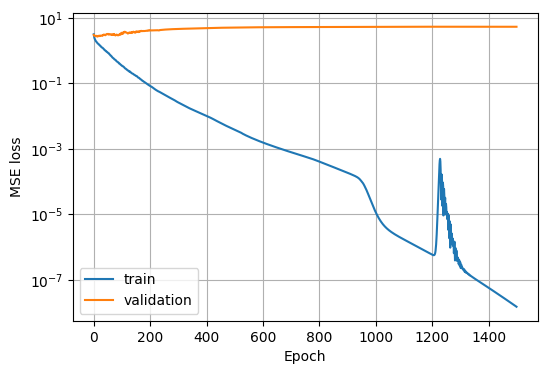

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history["loss"], label="train")
plt.plot(history["val_loss"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

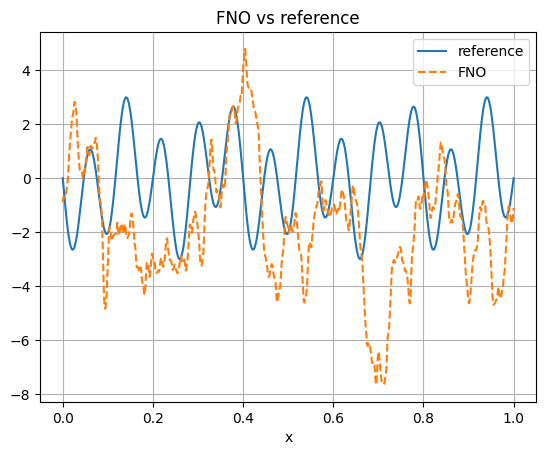

In [ ]:
# Plot the result of the FNO applied to the i-th test input. 

# Plot the solution.
x = np.linspace(0, 1, 1000)

# Compute the solution.
with torch.no_grad():
    inp = torch.from_numpy(x).reshape((1, len(x), 1)).to(torch.float32)
    pred = FNO(inp).squeeze().numpy()

_, ref = generate_data(x)

plt.plot(x, ref.squeeze(), label="reference")
plt.plot(x, pred, "--", label="FNO")
plt.legend()
plt.grid()
plt.xlabel("x")
plt.title("FNO vs reference")
plt.show()

In [ ]:
# Write the data to TensorBoard file for visualization.
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("results/summaries/FNO")

for i in range(len(history["loss"])):
    writer.add_scalar("loss/train", history["loss"][i], i)
    writer.add_scalar("loss/test/l1_istep", history["val_loss"][i], i)

writer.close()